# Introduction to Biostatistics - Modelling: Covariance & Correlation

**Part 6: Modeling**

## Covariance and Correlation

In a sample, we use the sample covariance and sample correlation to estimate the population values.

**Sample covariance:**
$$s_{XY} = \frac{1}{n-1} \sum_{i=1}^{n} (X_i - \bar{X})(Y_i - \bar{Y})$$

**Sample correlation:**
$$r_{XY} = \frac{s_{XY}}{s_X \, s_Y}$$

The correlation standardizes the covariance to lie between −1 and 1.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(1)

## The Diabetes Dataset

This dataset contains information about patients with diabetes, including age, cholesterol levels, and other health metrics.

- **Source:** [Vanderbilt Biostatistics Datasets](https://hbiostat.org/data/)
- **Data dictionary:** [cdiabetes](https://hbiostat.org/data/repo/cdiabetes)
- Willems JP, Saunders JT, et al. (1997). *Southern Medical Journal* 90:814–820
- Schorling JB, Roach J, et al. (1997). *Preventive Medicine* 26:92–101

In [2]:
data = pd.read_csv(
    "https://raw.githubusercontent.com/Decision-Academy/"
    "Intro-to-Biostatistics-with-Justin-Belair/refs/heads/main/data/diabetes.csv"
)
data.head()

,id,chol,stab.glu,hdl,ratio,glyhb,location,age,gender,height,weight,frame,bp.1s,bp.1d,bp.2s,bp.2d,waist,hip,time.ppn
0,1000,203.0,82,56.0,3.6,4.31,Buckingham,46,female,62.0,121.0,medium,118.0,59.0,NaN,NaN,29.0,38.0,720.0
1,1001,165.0,97,24.0,6.9,4.44,Buckingham,29,female,64.0,218.0,large,112.0,68.0,NaN,NaN,46.0,48.0,360.0
2,1002,228.0,92,37.0,6.2,4.64,Buckingham,58,female,61.0,256.0,large,190.0,92.0,185.0,92.0,49.0,57.0,180.0
3,1003,78.0,93,12.0,6.5,4.63,Buckingham,67,male,67.0,119.0,large,110.0,50.0,NaN,NaN,33.0,38.0,480.0
4,1005,249.0,90,28.0,8.9,7.72,Buckingham,64,male,68.0,183.0,medium,138.0,80.0,NaN,NaN,44.0,41.0,300.0


### Scatter Plot of Cholesterol vs Age

A scatter plot shows the relationship between two continuous variables.

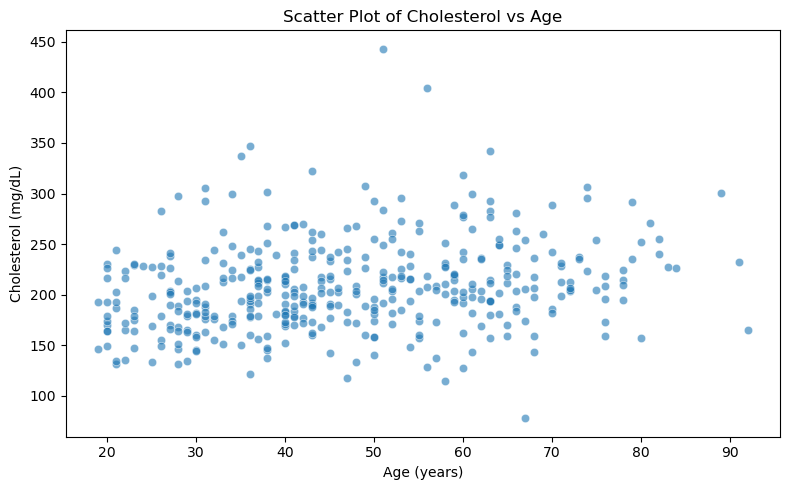

In [3]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=data, x='age', y='chol', alpha=0.6)
plt.title('Scatter Plot of Cholesterol vs Age')
plt.xlabel('Age (years)')
plt.ylabel('Cholesterol (mg/dL)')
plt.tight_layout()
plt.show()

### Compute Covariance and Correlation

In [4]:
# Remove rows with missing values in chol or age
data_complete = data[['chol', 'age']].dropna()

chol = data_complete['chol'].values
age = data_complete['age'].values

In [5]:
# Sample covariance (using ddof=1 for unbiased estimator)
# np.cov returns a 2x2 matrix; the off-diagonal is the covariance
cov_matrix = np.cov(chol, age, ddof=1)
covariance = cov_matrix[0, 1]
print("Covariance:", covariance)

Covariance: 169.2234215456384


In [6]:
# Sample correlation
# np.corrcoef returns a 2x2 matrix; the off-diagonal is the correlation
corr_matrix = np.corrcoef(chol, age)
correlation = corr_matrix[0, 1]
print("Correlation:", correlation)

Correlation: 0.23311911350994177


In [7]:
# Verify: correlation = covariance / (sd_chol * sd_age)
calculated_corr = covariance / (np.std(chol, ddof=1) * np.std(age, ddof=1))
print("Calculated correlation:", calculated_corr)

Calculated correlation: 0.23311911350994174
